In [12]:
import pandas as pd 
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import os
import re
import requests

In [10]:
from math import log2

def entropy(data):
    stat={}
    for b in data:
        if b in stat:
            stat[b]+=1
        else:
         stat[b]=1
    N=len(data)
    H=0
    for b in stat:
        p_i=stat[b]/N
        H-=p_i*log2(p_i)
    return H

In [11]:
STREET = "Warszawa"
OVERPASS_URL = "https://overpass-api.de/api/interpreter"
OPEN_METEO_URL = "https://api.open-meteo.com/v1/forecast"
OVERPASS_QUERY = f"""
[out:json][timeout:120];
area["name"="{STREET}"]->.a;
(
  way["highway"~"^(primary|secondary|tertiary)$"](area.a);
);
(._;>;);
out body;
"""
WARSAW_LAT = 52.2297
WARSAW_LON = 21.0122
weather_params = {
    "latitude": WARSAW_LAT,
    "longitude": WARSAW_LON,
    "hourly": ",".join([
        "temperature_2m",
        "precipitation",
        "rain",
        "snowfall",
        "wind_speed_10m",
        "visibility",
        "weather_code",
    ]),
    "forecast_days": 1,
    "timezone": "Europe/Warsaw",
    }
HEADERS = {
    # some dummy user-agent, some german words added, because of server sensitivity
    "User-Agent": "opennav-neu-werk Kontakt: opennav@freimail",
    "Accept": "application/json"
}

json_stats=[]
try:
    response = requests.get(OVERPASS_URL, params={'data': OVERPASS_QUERY}, headers=HEADERS)
    response.raise_for_status()
    raw_data = response.text
    json_stats.append({
        "filename":"overpass_street.json",
        "type":"json",
        "entropy":entropy(raw_data),
        "size": len(raw_data)
    })
    response = requests.get(OPEN_METEO_URL, params=weather_params)
    response.raise_for_status()
    raw_data = response.text
    json_stats.append({
        "filename":"weather.json",
        "type":"json",
        "entropy":entropy(raw_data),
        "size": len(raw_data)
    })
except Exception as e :
    print(e)

In [12]:
json_stats

[{'filename': 'overpass_street.json',
  'type': 'json',
  'entropy': 4.781659065612009,
  'size': 14080456},
 {'filename': 'weather.json',
  'type': 'json',
  'entropy': 4.158233441904661,
  'size': 1784}]

In [13]:
entropy_stats = []
for root, _, files in os.walk('../data/raw') :
    for file in files:
        if re.search(r"^[\.].*",file):
            # config files are not taken into account
            continue
        f = open(f'{root}/{file}',"rb")
        f_content = f.read()
        entropy_stats.append({
            "file":file,
            "type":file.split('.')[-1],
            "entropy":entropy(f_content),
            "size": len(f_content)
        })
        f.close()

In [15]:
entropy_stats = [*entropy_stats , *json_stats]

In [16]:
df_stats = pd.DataFrame(entropy_stats)
sns.set_style('whitegrid')

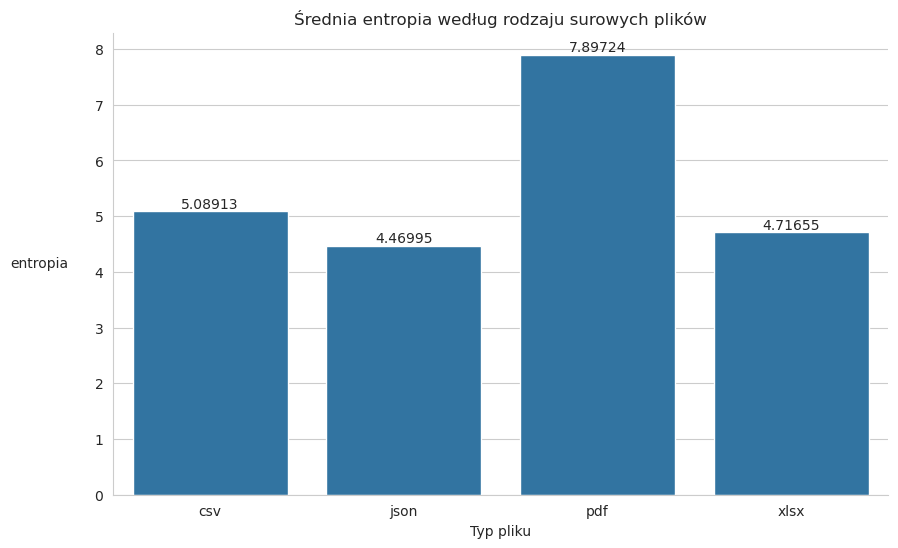

type
csv     5.089125
json    4.469946
pdf     7.897238
xlsx    4.716550
Name: entropy, dtype: float64


In [19]:
entropy_by_type = df_stats.groupby('type')['entropy'].mean()

plt.figure(figsize=(10,6))
ax=sns.barplot(entropy_by_type)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for container in ax.containers:
    ax.bar_label(container)
ax.set_title('Średnia entropia według rodzaju surowych plików')
ax.set_xlabel('Typ pliku')
ax.set_ylabel('entropia',rotation=0, labelpad=40, va='center')
plt.savefig('../docs/raport/png/avg_entropy_by_type.png')
plt.show()
print(entropy_by_type)

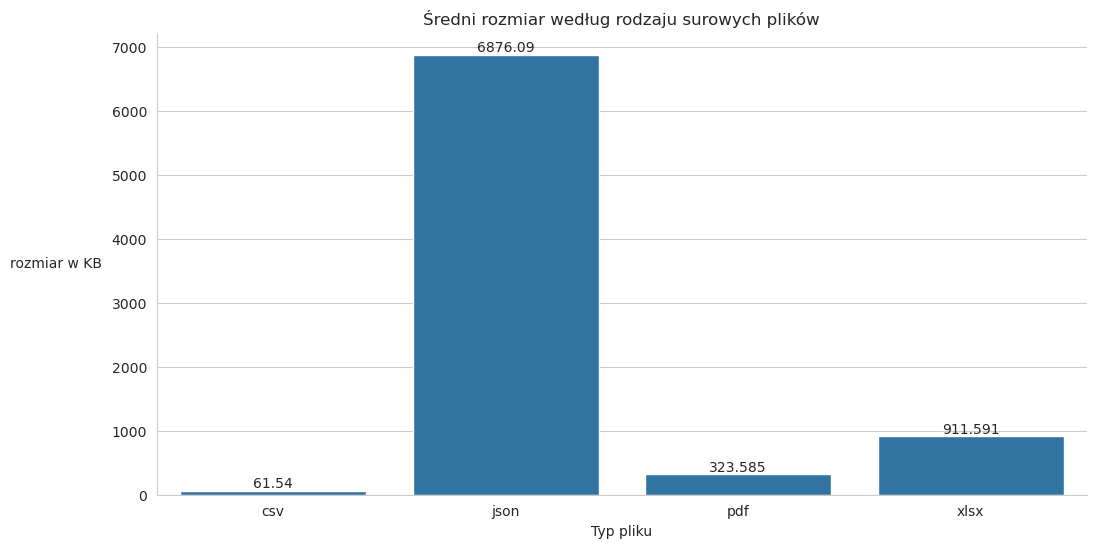

type
csv     6.301700e+04
json    7.041120e+06
pdf     3.313514e+05
xlsx    9.334690e+05
Name: size, dtype: float64


In [21]:
size_by_type = df_stats.groupby('type')['size'].mean()

plt.figure(figsize=(12,6))
ax=sns.barplot(size_by_type/1024)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for container in ax.containers:
    ax.bar_label(container)
ax.set_title('Średni rozmiar według rodzaju surowych plików')
ax.set_xlabel('Typ pliku')
ax.set_ylabel('rozmiar w KB',rotation=0, labelpad=40, va='center')
plt.savefig('../docs/raport/png/avg_size_by_type.png')
plt.show()
print(size_by_type)

In [21]:
zdm_traffic_by_road = pd.read_csv('../data/processed/zdm_traffic_by_road.csv')
zdm_speed_by_road = pd.read_csv('../data/processed/zdm_speed_by_road.csv')
osm_df = pd.read_parquet('../data/processed/osm_ways')

osm_streets = osm_df.name
zdm_traffic_share = np.sum(zdm_traffic_by_road.road_name.isin(osm_streets))/len(osm_streets)
zdm_speed_share = np.sum(zdm_speed_by_road.road_name.isin(osm_streets))/len(osm_streets)
print(f"Pokrycie dróg zdm (prędkość) w danych osm : {round(zdm_speed_share*100,2)} %")
print(f"Pokrycie dróg zdm (natężenie ruchu) w danych osm: {round(zdm_traffic_share*100,2)} %")

Pokrycie dróg zdm (prędkość) w danych osm : 0.53 %
Pokrycie dróg zdm (natężenie ruchu) w danych osm: 0.58 %


In [27]:
weather_df = pd.read_parquet('../data/processed/weather_observations')
print(f"Liczba stacji meteo: {len(weather_df)}")

Liczba stacji meteo: 24
